**Step 1: Environment Initialization & Code Extraction**


In [1]:
# 1. Reset the workspace environment completely
!rm -rf TrackNet-master TrackNet

# 2. Clone the authentic weekenddeeplearning repository structure
!git clone https://github.com/weekenddeeplearning/TrackNet.git
!mv TrackNet TrackNet-master

# 3. Force installation of compatible deep learning libraries
!pip install opencv-python pandas filterpy matplotlib tqdm

Cloning into 'TrackNet'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 70 (delta 2), reused 1 (delta 0), pack-reused 64 (from 1)
Receiving objects: 100% (70/70), 104.27 MiB | 31.92 MiB/s, done.
Resolving deltas: 100% (12/12), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=6fb7f1ca3ebe527cc05f7bc03326cb0d0e7d8188b6cdcbbac7b01671fb83f2e6
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


**Step 2: Mount Drive & High-Speed Dataset Extraction**


In [2]:
from google.colab import drive
import os
import shutil
import glob

# 1. Mount Google Drive
# Unmount and then mount to ensure a fresh connection
if os.path.exists('/content/drive'):
    drive.flush_and_unmount()
drive.mount('/content/drive')

# 2. Define path setups
drive_zip_path = '/content/drive/MyDrive/EE584_Project/Dataset.zip'
local_extract_base = '/content/TrackNet-master/Dataset_Images'

if os.path.exists(local_extract_base):
    shutil.rmtree(local_extract_base)
os.makedirs(local_extract_base, exist_ok=True)

# 3. Extract Archive Locally
if os.path.exists(drive_zip_path):
    print("Mirroring single zip archive to local high-speed workspace (seconds)...")
    local_zip_tmp = '/content/TrackNet-master/dataset_tmp.zip'
    shutil.copy2(drive_zip_path, local_zip_tmp)

    print("Extracting compressed image sequences to local SSD disk...")
    !unzip -q "{local_zip_tmp}" -d "{local_extract_base}"
    os.remove(local_zip_tmp)
    print("Extraction completed successfully!")
else:
    print(f"ERROR: Zipped data archive not found at path: {drive_zip_path}")

Mounted at /content/drive
Mirroring single zip archive to local high-speed workspace (seconds)...
Extracting compressed image sequences to local SSD disk...
Extraction completed successfully!


**Step 3: Shared Core Configurations & Dataset Freezing**


In [3]:
import os
import glob
import pandas as pd

local_extract_base = '/content/TrackNet-master/Dataset_Images'

def parse_flexible_csv(csv_path):
    """Safely reads the clip CSV regardless of header variations or hyphenated column names."""
    try:
        df = pd.read_csv(csv_path)
        df.columns = [str(c).strip().lower() for c in df.columns]
        if str(df.columns[0]).endswith('.jpg') or str(df.columns[0]).isdigit():
            df = pd.read_csv(csv_path, header=None)
            df.columns = ['frame', 'visibility', 'x', 'y']
        rename_map = {}
        for col in df.columns:
            if any(k in col for k in ['frame', 'file', 'img', 'image', 'name']): rename_map[col] = 'frame'
            elif any(k in col for k in ['vis', 'visibility']): rename_map[col] = 'visibility'
            elif 'x' in col: rename_map[col] = 'x'
            elif 'y' in col: rename_map[col] = 'y'
        return df.rename(columns=rename_map)
    except Exception:
        return None

# Discover all clip CSV arrays recursively
all_discovered_clips = sorted(glob.glob(os.path.join(local_extract_base, "**", "*.csv"), recursive=True))

# FREEZE SELECTION CONTEXT: Pull 5 explicit sequential clips to guarantee data alignment
frozen_demo_clips = all_discovered_clips[:5]

# Build the unified, aligned valid dataset structure
valid_clips_data = []
total_frame_workload = 0

for csv_path in frozen_demo_clips:
    df_clip = parse_flexible_csv(csv_path)
    if df_clip is not None and len(df_clip) >= 3:
        total_frame_workload += (len(df_clip) - 2)
        valid_clips_data.append((csv_path, df_clip))

print("="*60)
print(f"DATASET ALIGNMENT LOCKED: Both algorithms will process the EXACT same data.")
print(f"Total Workload: {total_frame_workload} frames across {len(valid_clips_data)} clips.")
print("="*60)
for c in frozen_demo_clips:
    print(f" -> Aligned Target Clip Location: {os.path.relpath(c, local_extract_base)}")

DATASET ALIGNMENT LOCKED: Both algorithms will process the EXACT same data.
Total Workload: 815 frames across 5 clips.
 -> Aligned Target Clip Location: Dataset/game1/Clip1/Label.csv
 -> Aligned Target Clip Location: Dataset/game1/Clip10/Label.csv
 -> Aligned Target Clip Location: Dataset/game1/Clip11/Label.csv
 -> Aligned Target Clip Location: Dataset/game1/Clip12/Label.csv
 -> Aligned Target Clip Location: Dataset/game1/Clip13/Label.csv


**Step 4: TrackNet Model II Inference & Verification Execution**


In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Shift active focus into Code_Tennis to safely pull model dependencies
%cd /content/TrackNet-master/Code_Tennis
from Models.TrackNet import TrackNet

weights_path = '/content/TrackNet-master/Code_Tennis/weights/model_tennis.h5'
width, height = 640, 360
n_classes = 256
pe_threshold = 5

m = TrackNet(n_classes, input_height=height, input_width=width)
m.compile(loss='categorical_crossentropy', optimizer='adadelta', metrics=['accuracy'])
m.load_weights(weights_path)
print("\nTrackNet Spatio-Temporal Model II successfully loaded with frozen weights.\n")

tracknet_tp, tracknet_fp, tracknet_fn = 0, 0, 0
tracknet_pe_list = []
tracknet_predictions = {}   # {frame_name -> (pred_x, pred_y)} for the verification video

with tqdm(total=total_frame_workload, desc="Evaluating TrackNet Model II", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t  = str(df_clip.iloc[i]['frame'])
            f_t1 = str(df_clip.iloc[i-1]['frame'])
            f_t2 = str(df_clip.iloc[i-2]['frame'])

            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')):
                f_t, f_t1, f_t2 = f_t + '.jpg', f_t1 + '.jpg', f_t2 + '.jpg'

            path_t  = os.path.join(clip_dir, f_t)
            path_t1 = os.path.join(clip_dir, f_t1)
            path_t2 = os.path.join(clip_dir, f_t2)

            if not (os.path.exists(path_t) and os.path.exists(path_t1) and os.path.exists(path_t2)):
                continue

            raw_frame = cv2.imread(path_t)
            if raw_frame is None: continue
            orig_h, orig_w, _ = raw_frame.shape

            img  = cv2.resize(raw_frame, (width, height)).astype(np.float32)
            img1 = cv2.resize(cv2.imread(path_t1), (width, height)).astype(np.float32)
            img2 = cv2.resize(cv2.imread(path_t2), (width, height)).astype(np.float32)

            X = np.concatenate((img, img1, img2), axis=2)
            X = np.rollaxis(X, 2, 0)

            pr = m.predict(np.array([X]), verbose=0)[0]
            pr = pr.reshape((height, width, n_classes)).argmax(axis=2).astype(np.uint8)

            heatmap_resized = cv2.resize(pr, (orig_w, orig_h))
            _, heatmap = cv2.threshold(heatmap_resized, 127, 255, cv2.THRESH_BINARY)

            circles = cv2.HoughCircles(heatmap, cv2.HOUGH_GRADIENT, dp=1, minDist=1,
                                       param1=50, param2=2, minRadius=2, maxRadius=7)

            vc_pred = 1 if circles is not None else 0
            pred_x = int(circles[0][0][0]) if vc_pred == 1 else 0
            pred_y = int(circles[0][0][1]) if vc_pred == 1 else 0

            # Capture SoTA centroid for the annotated verification video (Step 9)
            if vc_pred == 1:
                tracknet_predictions[f_t] = (pred_x, pred_y)

            if vc_gt == 0:
                if vc_pred == 1: tracknet_fp += 1
            else:
                if vc_pred == 0: tracknet_fn += 1
                else:
                    pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                    tracknet_pe_list.append(pe)
                    if pe <= pe_threshold: tracknet_tp += 1
                    else: tracknet_fp += 1

# Compile TrackNet Report
tn_precision = tracknet_tp / (tracknet_tp + tracknet_fp) if (tracknet_tp + tracknet_fp) > 0 else 0
tn_recall = tracknet_tp / (tracknet_tp + tracknet_fn) if (tracknet_tp + tracknet_fn) > 0 else 0
tn_f1 = 2 * (tn_precision * tn_recall) / (tn_precision + tn_recall) if (tn_precision + tn_recall) > 0 else 0
tn_mean_pe = np.mean(tracknet_pe_list) if len(tracknet_pe_list) > 0 else 0

print("\n" + "="*60)
print("     [SOTA DEEP LEARNING] TRACKNET MODEL II VERIFICATION REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Classification Precision: {tn_precision * 100:.2f}%")
print(f"Classification Recall:    {tn_recall * 100:.2f}%")
print(f"Classification F1-Score:  {tn_f1 * 100:.2f}%")
print(f"Mean Positioning Error:   {tn_mean_pe:.2f} pixels")
print("="*60 + "\n")

/content/TrackNet-master/Code_Tennis
layer24 output shape: 256 360 640


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9, 360, 640)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 360, 640)   │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 360, 640)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 360, 640)   │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 360, 640)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 360, 640)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 360, 640)   │         2,560 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 180, 320)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 180, 320)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 180, 320)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 180, 320)  │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 180, 320)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 180, 320)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 180, 320)  │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 90, 160)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 90, 160)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256, 90, 160)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 90, 160)   │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 90, 160)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256, 90, 160)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256, 90, 160)   │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 90, 160)   │       590,08

 Total params: 10,722,560 (40.90 MB)

 Trainable params: 10,711,200 (40.86 MB)

 Non-trainable params: 11,360 (44.38 KB)


TrackNet Spatio-Temporal Model II successfully loaded with frozen weights.



Evaluating TrackNet Model II: 100%|██████████| 815/815 [05:22<00:00,  2.52frame/s]


     [SOTA DEEP LEARNING] TRACKNET MODEL II VERIFICATION REPORT
Total Evaluated Frames:  815
Classification Precision: 97.94%
Classification Recall:    95.84%
Classification F1-Score:  96.88%
Mean Positioning Error:   4.48 pixels



**Step 5: MOG2 + Kalman Filter CV Baseline & Verification Execution**


In [5]:
import os
import cv2
import numpy as np
from tqdm import tqdm

kalman_pe_list = []
total_detections_made_by_kf = 0

# COAST CAP: stop declaring a lock after N consecutive measurement-free (dead-reckoning)
# frames, so pure Kalman extrapolation during long occlusions does not pollute the PE log.
MAX_COAST = 5

with tqdm(total=total_frame_workload, desc="Evaluating MOG2 + Kalman Filter", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        fgbg = cv2.createBackgroundSubtractorMOG2(history=50, varThreshold=30, detectShadows=False)

        kf = cv2.KalmanFilter(4, 2, 0)
        kf.transitionMatrix = np.array([[1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0], [0, 0, 0, 1]], dtype=np.float32)
        kf.measurementMatrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0]], dtype=np.float32)
        kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
        kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1
        kf.errorCovPost = np.eye(4, dtype=np.float32)
        kf_initialized = False
        coast_count = 0   # consecutive prediction-only frames

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t = str(gt_row['frame'])
            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'

            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t): continue

            frame = cv2.imread(path_t)
            orig_h, orig_w, _ = frame.shape

            blurred = cv2.GaussianBlur(frame, (3, 3), 0)
            fg_mask = fgbg.apply(blurred)

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
            closing = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
            contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            measurement_found = False
            meas_x, meas_y = 0, 0
            best_circularity = 0

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if 5 <= area <= 250:
                    perimeter = cv2.arcLength(cnt, True)
                    if perimeter == 0: continue
                    circularity = (4 * np.pi * area) / (perimeter ** 2)

                    if circularity > 0.4 and circularity > best_circularity:
                        M = cv2.moments(cnt)
                        if M["m00"] != 0:
                            meas_x = float(M["m10"] / M["m00"])
                            meas_y = float(M["m01"] / M["m00"])
                            measurement_found = True
                            best_circularity = circularity

            prediction = kf.predict()

            if measurement_found:
                if not kf_initialized:
                    kf.statePost = np.array([[meas_x], [meas_y], [0], [0]], dtype=np.float32)
                    kf_initialized = True
                    pred_x, pred_y = int(meas_x), int(meas_y)
                else:
                    measurement = np.array([[meas_x], [meas_y]], dtype=np.float32)
                    correction = kf.correct(measurement)
                    pred_x, pred_y = int(correction[0][0]), int(correction[1][0])
                vc_pred = 1
                coast_count = 0   # fresh appearance evidence resets the coast counter
            else:
                if kf_initialized and coast_count < MAX_COAST:
                    pred_x, pred_y = int(prediction[0][0]), int(prediction[1][0])
                    vc_pred = 1
                    coast_count += 1   # extrapolating without appearance evidence
                else:
                    pred_x, pred_y = 0, 0
                    vc_pred = 0

            # LOCALIZATION ASSESSMENT: Calculate positioning tracking error when both ball and lock co-exist
            if vc_gt == 1 and vc_pred == 1:
                total_detections_made_by_kf += 1
                pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                kalman_pe_list.append(pe)

# Compile Kalman Report
kf_mean_pe = np.mean(kalman_pe_list) if len(kalman_pe_list) > 0 else 0
kf_success_at_5 = (np.mean(np.array(kalman_pe_list) <= pe_threshold) * 100
                   if len(kalman_pe_list) > 0 else 0)
print("\n" + "="*60)
print("     [KINEMATIC BASELINE] MOG2 + KALMAN FILTER LOCALIZATION REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_detections_made_by_kf} frames")
print(f"Mean Positioning Error:  {kf_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {kf_success_at_5:.2f}% of locks")
print("="*60 + "\n")

Evaluating MOG2 + Kalman Filter: 100%|██████████| 815/815 [00:10<00:00, 80.91frame/s]


     [KINEMATIC BASELINE] MOG2 + KALMAN FILTER LOCALIZATION REPORT
Total Evaluated Frames:  815
Active Locks Registered: 680 frames
Mean Positioning Error:  172.07 pixels
Success @ PE<=5px:      5.29% of locks



**Step 6: HSV Color Segmentation Appearance Baseline**


In [6]:
import os
import cv2
import numpy as np
from tqdm import tqdm

hsv_pe_list = []
total_detections_made_by_hsv = 0

lower_tennis_yellow = np.array([25, 50, 50])
upper_tennis_yellow = np.array([55, 255, 255])

with tqdm(total=total_frame_workload, desc="Evaluating HSV Appearance Filter", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t = str(gt_row['frame'])
            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'

            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t): continue

            frame = cv2.imread(path_t)
            orig_h, orig_w, _ = frame.shape

            hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            color_mask = cv2.inRange(hsv_frame, lower_tennis_yellow, upper_tennis_yellow)

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
            clean_mask = cv2.morphologyEx(color_mask, cv2.MORPH_OPEN, kernel)
            contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            vc_pred = 0
            pred_x, pred_y = 0, 0
            best_circularity = 0

            for cnt in contours:
                area = cv2.contourArea(cnt)
                if 4 <= area <= 200:
                    perimeter = cv2.arcLength(cnt, True)
                    if perimeter == 0: continue
                    circularity = (4 * np.pi * area) / (perimeter ** 2)

                    if circularity > 0.3 and circularity > best_circularity:
                        M = cv2.moments(cnt)
                        if M["m00"] != 0:
                            pred_x = int(M["m10"] / M["m00"])
                            pred_y = int(M["m01"] / M["m00"])
                            vc_pred = 1
                            best_circularity = circularity

            # LOCALIZATION ASSESSMENT: Log tracking precision distance
            if vc_gt == 1 and vc_pred == 1:
                total_detections_made_by_hsv += 1
                pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                hsv_pe_list.append(pe)

# Compile HSV Report
hsv_mean_pe = np.mean(hsv_pe_list) if len(hsv_pe_list) > 0 else 0
hsv_success_at_5 = (np.mean(np.array(hsv_pe_list) <= pe_threshold) * 100
                    if len(hsv_pe_list) > 0 else 0)
print("\n" + "="*60)
print("     [APPEARANCE BASELINE] HSV COLOR SEGMENTATION LOCALIZATION REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_detections_made_by_hsv} frames")
print(f"Mean Positioning Error:  {hsv_mean_pe:.2f} pixels (Bottomed out if 0)")
print(f"Success @ PE<={pe_threshold}px:      {hsv_success_at_5:.2f}% of locks")
print("="*60 + "\n")

Evaluating HSV Appearance Filter: 100%|██████████| 815/815 [00:06<00:00, 130.72frame/s]


     [APPEARANCE BASELINE] HSV COLOR SEGMENTATION LOCALIZATION REPORT
Total Evaluated Frames:  815
Active Locks Registered: 685 frames
Mean Positioning Error:  393.09 pixels (Bottomed out if 0)
Success @ PE<=5px:      0.00% of locks



**Step 7: CAMShift Appearance-Tracker Baseline**


In [7]:
# ==============================================================================
#  BASELINE #4: CAMShift (Continuously Adaptive Mean Shift)
# ------------------------------------------------------------------------------
#  PARADIGM:  Appearance / color-histogram mode-seeking (CAUSAL tracker).
#  CONTRAST vs HSV cell: HSV is a *stateless detector* (re-segments every frame).
#  CAMShift is a *stateful tracker* -- initialized once from the first confident
#  GT frame, builds a hue back-projection model, then mean-shifts the search
#  window toward the color centroid frame-to-frame, adapting the window size.
#  EXPECTED FAILURE (report criterion B): once the small/blurred ball is lost,
#  the mode-seek latches onto the dominant background color cluster (court,
#  lines, kit) and drifts -- PE explodes. This is the bonus "make it fail" case.
# ==============================================================================
import os
import cv2
import numpy as np
from tqdm import tqdm

camshift_pe_list = []
total_locks_camshift = 0

# Tennis-ball hue band (same family as the HSV cell, tightened for the histogram model)
CAMSHIFT_LOWER = np.array([25, 60, 60])
CAMSHIFT_UPPER = np.array([45, 255, 255])
CAMSHIFT_WIN   = 20   # half-size (px) of the initial search window seeded on GT
CAMSHIFT_TERM  = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

with tqdm(total=total_frame_workload, desc="Evaluating CAMShift", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        # --- PER-CLIP TRACKER STATE (reset at every clip boundary) ---
        track_window = None   # (x, y, w, h); None => awaiting (re)acquisition
        roi_hist     = None   # hue histogram = the target appearance model

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t = str(gt_row['frame'])
            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'
            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t): continue

            frame = cv2.imread(path_t)
            if frame is None: continue
            orig_h, orig_w, _ = frame.shape

            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            pred_x, pred_y, vc_pred = 0, 0, 0   # default: lost

            if track_window is None:
                # ---- (RE)ACQUISITION: bootstrap the model from a confident GT frame ----
                # A causal tracker MUST be given a start box. We seed from ground truth,
                # then the tracker runs fully autonomously from the next frame onward.
                if vc_gt == 1:
                    cx, cy = int(gt_x), int(gt_y)
                    x0 = max(0, cx - CAMSHIFT_WIN); y0 = max(0, cy - CAMSHIFT_WIN)
                    x1 = min(orig_w, cx + CAMSHIFT_WIN); y1 = min(orig_h, cy + CAMSHIFT_WIN)
                    track_window = (x0, y0, x1 - x0, y1 - y0)

                    roi = hsv[y0:y1, x0:x1]
                    roi_mask = cv2.inRange(roi, CAMSHIFT_LOWER, CAMSHIFT_UPPER)
                    roi_hist = cv2.calcHist([roi], [0], roi_mask, [16], [0, 180])
                    cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
                    pred_x, pred_y, vc_pred = cx, cy, 1   # acquisition frame is a lock
            else:
                # ---- TRACK: back-project the hue model and mean-shift the window ----
                back_proj = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
                ret, track_window = cv2.CamShift(back_proj, track_window, CAMSHIFT_TERM)
                (cx, cy), (bw, bh), _ = ret
                area = bw * bh

                # LOCK-LOSS TEST: window collapsed, exploded (drifted onto background),
                # or wandered off-frame  =>  declare loss, force re-acquisition next frame.
                if area < 2 or area > (CAMSHIFT_WIN * CAMSHIFT_WIN * 9) \
                   or cx <= 0 or cy <= 0 or cx >= orig_w or cy >= orig_h:
                    track_window = None
                else:
                    pred_x, pred_y, vc_pred = cx, cy, 1

            # LOCALIZATION ASSESSMENT (Euclidean PE; logged only on co-occurring lock)
            if vc_gt == 1 and vc_pred == 1:
                total_locks_camshift += 1
                pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                camshift_pe_list.append(pe)

# Compile CAMShift Report
camshift_mean_pe = np.mean(camshift_pe_list) if len(camshift_pe_list) > 0 else 0
camshift_success_at_5 = (np.mean(np.array(camshift_pe_list) <= pe_threshold) * 100
                         if len(camshift_pe_list) > 0 else 0)
print("\n" + "="*60)
print("     [APPEARANCE-TRACKER BASELINE] CAMSHIFT LOCALIZATION REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_locks_camshift} frames")
print(f"Mean Positioning Error:  {camshift_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {camshift_success_at_5:.2f}% of locks")
print("="*60 + "\n")

Evaluating CAMShift: 100%|██████████| 815/815 [00:04<00:00, 179.57frame/s]


     [APPEARANCE-TRACKER BASELINE] CAMSHIFT LOCALIZATION REPORT
Total Evaluated Frames:  815
Active Locks Registered: 438 frames
Mean Positioning Error:  77.77 pixels
Success @ PE<=5px:      63.01% of locks



**Step 8: Lucas-Kanade Sparse Optical Flow Baseline**


In [8]:
# ==============================================================================
#  BASELINE #5: Lucas-Kanade Sparse Optical Flow
# ------------------------------------------------------------------------------
#  PARADIGM:  Motion / geometric tracking via the brightness-constancy constraint
#             I_x*u + I_y*v + I_t = 0, solved per feature over a local window
#             (pyramidal, to extend the trackable displacement range).
#  PROCEDURE: Seed Shi-Tomasi corners (goodFeaturesToTrack) inside a GT-centered
#             window, then propagate those points frame-to-frame with PyrLK.
#             Predicted ball position = centroid of surviving tracked features.
#  EXPECTED FAILURE (report criterion B): the ball is small, low-texture, and
#  FAST. When per-frame displacement exceeds the pyramid search radius, the flow
#  estimate lags or snaps to high-gradient background (court lines) -- PE grows
#  and features die. This is the cleanest demonstration of WHY TrackNet's learned
#  trajectory prior beats a local first-order motion model on high-speed objects.
# ==============================================================================
import os
import cv2
import numpy as np
from tqdm import tqdm

lk_pe_list = []
total_locks_lk = 0

LK_WIN    = 20   # half-size (px) of the GT-seeded feature-search window
LK_PARAMS = dict(winSize=(15, 15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
GFTT_PARAMS = dict(maxCorners=10, qualityLevel=0.01, minDistance=3, blockSize=7)

with tqdm(total=total_frame_workload, desc="Evaluating Lucas-Kanade", unit="frame") as pbar:
    for csv_path, df_clip in sorted(valid_clips_data, key=lambda x: x[0]):
        clip_dir = os.path.dirname(csv_path)

        # --- PER-CLIP TRACKER STATE ---
        prev_gray = None    # previous grayscale frame (the I_{t-1} reference)
        p0        = None    # current tracked feature points (None => need re-seed)

        for i in range(2, len(df_clip)):
            pbar.update(1)

            gt_row = df_clip.iloc[i]
            vc_gt = int(float(gt_row['visibility']))
            gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])

            f_t = str(gt_row['frame'])
            if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'
            path_t = os.path.join(clip_dir, f_t)
            if not os.path.exists(path_t): continue

            frame = cv2.imread(path_t)
            if frame is None: continue
            orig_h, orig_w, _ = frame.shape
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            pred_x, pred_y, vc_pred = 0, 0, 0   # default: lost

            if p0 is None or prev_gray is None:
                # ---- (RE)SEED features inside a GT-centered window ----
                if vc_gt == 1:
                    cx, cy = int(gt_x), int(gt_y)
                    x0 = max(0, cx - LK_WIN); y0 = max(0, cy - LK_WIN)
                    x1 = min(orig_w, cx + LK_WIN); y1 = min(orig_h, cy + LK_WIN)
                    roi = gray[y0:y1, x0:x1]
                    feats = cv2.goodFeaturesToTrack(roi, **GFTT_PARAMS)
                    if feats is not None:
                        # shift ROI-local corner coords back into full-frame coords
                        feats = feats.reshape(-1, 2) + np.array([x0, y0], dtype=np.float32)
                        p0 = feats.reshape(-1, 1, 2).astype(np.float32)
                        pred_x, pred_y, vc_pred = cx, cy, 1   # seed frame is a lock
            else:
                # ---- TRACK: propagate features by pyramidal LK optical flow ----
                p1, st, err = cv2.calcOpticalFlowPyrLK(prev_gray, gray, p0, None, **LK_PARAMS)
                if p1 is not None and st is not None:
                    good = p1[st.flatten() == 1].reshape(-1, 2)
                    if len(good) >= 1:
                        c = good.mean(axis=0)   # ball estimate = centroid of survivors
                        pred_x, pred_y = float(c[0]), float(c[1])
                        if 0 < pred_x < orig_w and 0 < pred_y < orig_h:
                            vc_pred = 1
                            p0 = good.reshape(-1, 1, 2).astype(np.float32)
                        else:
                            p0 = None   # drifted off-frame => force re-seed
                    else:
                        p0 = None       # all features died => lost
                else:
                    p0 = None

            prev_gray = gray

            # LOCALIZATION ASSESSMENT
            if vc_gt == 1 and vc_pred == 1:
                total_locks_lk += 1
                pe = np.sqrt((gt_x - pred_x)**2 + (gt_y - pred_y)**2)
                lk_pe_list.append(pe)

# Compile Lucas-Kanade Report
lk_mean_pe = np.mean(lk_pe_list) if len(lk_pe_list) > 0 else 0
lk_success_at_5 = (np.mean(np.array(lk_pe_list) <= pe_threshold) * 100
                   if len(lk_pe_list) > 0 else 0)
print("\n" + "="*60)
print("     [MOTION-TRACKER BASELINE] LUCAS-KANADE OPTICAL FLOW REPORT")
print("="*60)
print(f"Total Evaluated Frames:  {total_frame_workload}")
print(f"Active Locks Registered: {total_locks_lk} frames")
print(f"Mean Positioning Error:  {lk_mean_pe:.2f} pixels")
print(f"Success @ PE<={pe_threshold}px:      {lk_success_at_5:.2f}% of locks")
print("="*60 + "\n")

Evaluating Lucas-Kanade: 100%|██████████| 815/815 [00:04<00:00, 173.42frame/s]


     [MOTION-TRACKER BASELINE] LUCAS-KANADE OPTICAL FLOW REPORT
Total Evaluated Frames:  815
Active Locks Registered: 682 frames
Mean Positioning Error:  196.31 pixels
Success @ PE<=5px:      1.91% of locks



**Step 9: Final Verification Video (Annotated Frame-Sequence Compilation)**


In [9]:
# ==============================================================================
#  FINAL VERIFICATION VIDEO  (frame-sequence -> annotated .mp4)
# ------------------------------------------------------------------------------
#  DRAWING LAYER RULE (strict):
#     - TrackNet (SoTA)      -> RED  filled CIRCLE
#     - Classical baseline   -> ORANGE  TRIANGLE   (CAMShift; swap to LK if desired)
#     - Ground Truth         -> GREEN  hollow SQUARE
#     - Trailing alpha-blended trajectory line (ball-path history for GT + classical)
#  The TrackNet layer is drawn from the tracknet_predictions dict populated in Step 4.
# ==============================================================================
import os
import cv2
import numpy as np

# --- Choose which clip to visualize (first frozen clip) ---
viz_csv_path, viz_df = sorted(valid_clips_data, key=lambda x: x[0])[0]
viz_clip_dir = os.path.dirname(viz_csv_path)
OUTPUT_VIDEO = "/content/verification_dataset1.mp4"

# TrackNet hits captured in Step 4 ({frame_name -> (x, y)}); empty-safe fallback.
tracknet_predictions = globals().get("tracknet_predictions", {})

# ---- Re-instantiate the classical (CAMShift) tracker state for this clip ----
LOWER = np.array([25, 60, 60]); UPPER = np.array([45, 255, 255]); WIN = 20
TERM  = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
track_window, roi_hist = None, None

# Probe the first usable frame for video dimensions
def _resolve(name):
    n = str(name)
    if not n.lower().endswith(('.jpg', '.png', '.jpeg')): n += '.jpg'
    return os.path.join(viz_clip_dir, n)

_probe = cv2.imread(_resolve(viz_df.iloc[2]['frame']))
H, W = _probe.shape[:2]
writer = cv2.VideoWriter(OUTPUT_VIDEO, cv2.VideoWriter_fourcc(*'mp4v'), 25.0, (W, H))

gt_trail, pred_trail = [], []   # trajectory-history buffers

def draw_triangle(img, cx, cy, color, s=9):
    pts = np.array([[cx, cy - s], [cx - s, cy + s], [cx + s, cy + s]], np.int32)
    cv2.polylines(img, [pts], True, color, 2)

for i in range(2, len(viz_df)):
    gt_row = viz_df.iloc[i]
    vc_gt = int(float(gt_row['visibility']))
    gt_x, gt_y = float(gt_row['x']), float(gt_row['y'])
    f_t = str(gt_row['frame'])
    if not f_t.lower().endswith(('.jpg', '.png', '.jpeg')): f_t += '.jpg'
    path_t = os.path.join(viz_clip_dir, f_t)
    if not os.path.exists(path_t): continue
    frame = cv2.imread(path_t)
    if frame is None: continue
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # --- classical (CAMShift) inference, identical logic to the Step 7 eval cell ---
    pred_x, pred_y, vc_pred = 0, 0, 0
    if track_window is None:
        if vc_gt == 1:
            cx, cy = int(gt_x), int(gt_y)
            x0, y0 = max(0, cx - WIN), max(0, cy - WIN)
            x1, y1 = min(W, cx + WIN), min(H, cy + WIN)
            track_window = (x0, y0, x1 - x0, y1 - y0)
            roi = hsv[y0:y1, x0:x1]
            roi_hist = cv2.calcHist([roi], [0], cv2.inRange(roi, LOWER, UPPER), [16], [0, 180])
            cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
            pred_x, pred_y, vc_pred = cx, cy, 1
    else:
        bp = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
        ret, track_window = cv2.CamShift(bp, track_window, TERM)
        (cx, cy), (bw, bh), _ = ret
        if (bw * bh) < 2 or (bw * bh) > WIN*WIN*9 or cx <= 0 or cy <= 0 or cx >= W or cy >= H:
            track_window = None
        else:
            pred_x, pred_y, vc_pred = cx, cy, 1

    overlay = frame.copy()

    # --- trajectory history (alpha-blended) ---
    if vc_gt == 1:   gt_trail.append((int(gt_x), int(gt_y)))
    if vc_pred == 1: pred_trail.append((int(pred_x), int(pred_y)))
    for trail, col in [(gt_trail, (0, 255, 0)), (pred_trail, (0, 165, 255))]:
        for k in range(1, len(trail)):
            cv2.line(overlay, trail[k-1], trail[k], col, 2)
    cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)   # alpha blend trail onto frame

    # --- LAYER 1: Ground Truth = GREEN hollow SQUARE ---
    if vc_gt == 1:
        cv2.rectangle(frame, (int(gt_x)-7, int(gt_y)-7), (int(gt_x)+7, int(gt_y)+7), (0,255,0), 2)
    # --- LAYER 2: Classical baseline (CAMShift) = ORANGE TRIANGLE ---
    if vc_pred == 1:
        draw_triangle(frame, int(pred_x), int(pred_y), (0, 165, 255))
    # --- LAYER 3: TrackNet (SoTA) = RED filled CIRCLE ---
    if f_t in tracknet_predictions:
        tx, ty = tracknet_predictions[f_t]
        cv2.circle(frame, (int(tx), int(ty)), 6, (0, 0, 255), -1)

    writer.write(frame)

writer.release()
print(f"Annotated verification video written -> {OUTPUT_VIDEO}")
print("Legend:  RED circle = TrackNet (SoTA)   |   ORANGE triangle = CAMShift   |   GREEN square = Ground Truth")

Annotated verification video written -> /content/verification_dataset1.mp4
Legend:  RED circle = TrackNet (SoTA)   |   ORANGE triangle = CAMShift   |   GREEN square = Ground Truth


**Step 10: Consolidated Five-Way Positioning-Error Distribution**


Generating consolidated five-way tracking localization chart for report presentation...


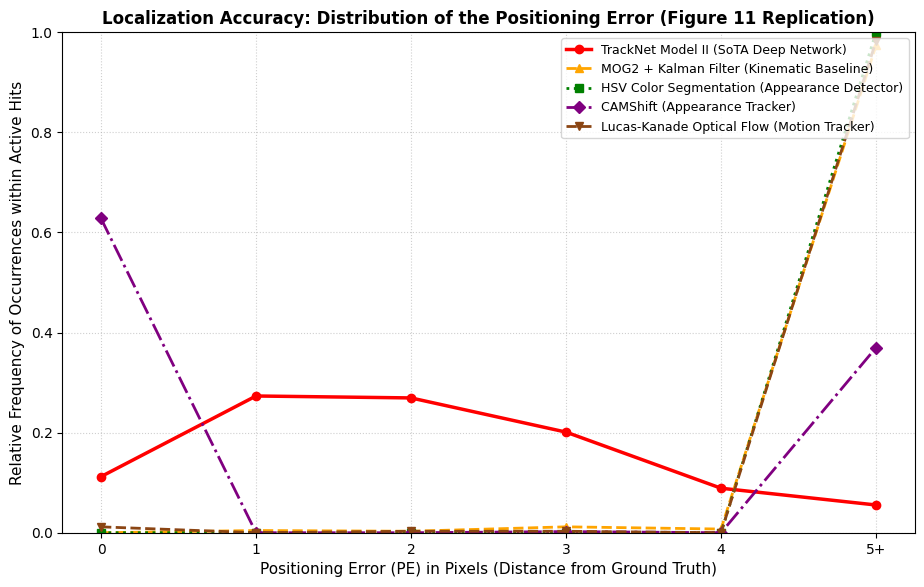

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def generate_five_way_error_chart(tn_errors, kf_errors, hsv_errors, camshift_errors, lk_errors):
    labels = ['0', '1', '2', '3', '4', '5+']

    def process_bins(error_list):
        if len(error_list) == 0: return [0]*6   # Safely intercepts empty lock arrays
        arr = np.array(error_list)
        total = len(arr)
        pcts = [np.sum(arr == 0) / total]
        for b in range(1, 5):
            pcts.append(np.sum((arr > b-1) & (arr <= b)) / total)
        pcts.append(np.sum(arr > 4) / total)
        return pcts

    tn_percentages       = process_bins(tn_errors)
    kf_percentages       = process_bins(kf_errors)
    hsv_percentages      = process_bins(hsv_errors)
    camshift_percentages = process_bins(camshift_errors)
    lk_percentages       = process_bins(lk_errors)

    plt.figure(figsize=(11, 6.5))

    # TrackNet (Solid Red, Circle) -- SoTA reference
    plt.plot(labels, tn_percentages, marker='o', color='red', linestyle='-', linewidth=2.5,
             label='TrackNet Model II (SoTA Deep Network)')
    # MOG2 + Kalman (Dashed Orange, Triangle)
    plt.plot(labels, kf_percentages, marker='^', color='orange', linestyle='--', linewidth=2,
             label='MOG2 + Kalman Filter (Kinematic Baseline)')
    # HSV (Dotted Green, Square) -- stateless appearance detector
    plt.plot(labels, hsv_percentages, marker='s', color='green', linestyle=':', linewidth=2,
             label='HSV Color Segmentation (Appearance Detector)')
    # CAMShift (Dash-dot Purple, Diamond) -- stateful appearance tracker
    plt.plot(labels, camshift_percentages, marker='D', color='purple', linestyle='-.', linewidth=2,
             label='CAMShift (Appearance Tracker)')
    # Lucas-Kanade (Dashed Brown, Inverted triangle) -- motion tracker
    plt.plot(labels, lk_percentages, marker='v', color='saddlebrown', linestyle='--', linewidth=2,
             label='Lucas-Kanade Optical Flow (Motion Tracker)')

    plt.title('Localization Accuracy: Distribution of the Positioning Error (Figure 11 Replication)',
              fontsize=12, fontweight='bold')
    plt.xlabel('Positioning Error (PE) in Pixels (Distance from Ground Truth)', fontsize=11)
    plt.ylabel('Relative Frequency of Occurrences within Active Hits', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.ylim(0, 1.0)
    plt.legend(fontsize=9, loc='upper right')

    print("Generating consolidated five-way tracking localization chart for report presentation...")
    plt.show()

# Render the five-way comparison graph
generate_five_way_error_chart(tracknet_pe_list, kalman_pe_list, hsv_pe_list,
                              camshift_pe_list, lk_pe_list)

**Step 11: Consolidated Quantitative Summary Table**


In [11]:
import numpy as np

def _mean(lst):   return np.mean(lst) if len(lst) > 0 else 0.0
def _succ(lst):   return (np.mean(np.array(lst) <= pe_threshold) * 100) if len(lst) > 0 else 0.0

rows = [
    ("TrackNet Model II (SoTA)",      len(tracknet_pe_list), _mean(tracknet_pe_list), _succ(tracknet_pe_list)),
    ("MOG2 + Kalman (Kinematic)",     len(kalman_pe_list),   _mean(kalman_pe_list),   _succ(kalman_pe_list)),
    ("HSV Segmentation (Appearance)", len(hsv_pe_list),      _mean(hsv_pe_list),      _succ(hsv_pe_list)),
    ("CAMShift (Appearance Tracker)", len(camshift_pe_list), _mean(camshift_pe_list), _succ(camshift_pe_list)),
    ("Lucas-Kanade (Motion Tracker)", len(lk_pe_list),       _mean(lk_pe_list),       _succ(lk_pe_list)),
]

print("="*78)
print(f"  DATASET 1 (CONTROL / BROADCAST VIEW) -- LOCALIZATION SUMMARY  | PE thr = {pe_threshold}px")
print("="*78)
print(f"{'Method':<34}{'Locks':>8}{'Mean PE (px)':>16}{'Success@thr':>16}")
print("-"*78)
for name, locks, mpe, succ in rows:
    print(f"{name:<34}{locks:>8}{mpe:>16.2f}{succ:>15.2f}%")
print("="*78)

  DATASET 1 (CONTROL / BROADCAST VIEW) -- LOCALIZATION SUMMARY  | PE thr = 5px
Method                               Locks    Mean PE (px)     Success@thr
------------------------------------------------------------------------------
TrackNet Model II (SoTA)               776            4.48          97.94%
MOG2 + Kalman (Kinematic)              680          172.07           5.29%
HSV Segmentation (Appearance)          685          393.09           0.00%
CAMShift (Appearance Tracker)          438           77.77          63.01%
Lucas-Kanade (Motion Tracker)          682          196.31           1.91%
